<a href="https://colab.research.google.com/github/Nurzhalil/Nurzhalil/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_7_SVM_%D0%B8_%D0%B3%D1%80%D0%B0%D0%BD%D0%B8%D1%86%D1%8B_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B9_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **SVM и границы решений. Ядерный переход (Kernel Trick). Оптимизация зазора между классами**

### **Задание 2: Ядро RBF (Radial Basis Function)**

В реальном мире данные редко бывают идеально линейно разделимыми. Когда классы перемешаны или имеют сложную форму (например, вложенные круги или изгибы), обычная прямая линия не сможет их эффективно разделить. Здесь на помощь приходит **ядерный переход (Kernel Trick)**.

**Ядро RBF** — одно из самых популярных ядер в SVM. Оно позволяет модели строить нелинейные границы решений, фактически проецируя данные в пространство более высокой размерности, где они становятся линейно разделимыми.

**Цели задания:**
1.  **Генерация нелинейных данных**: Использовать набор данных `make_moons`.
2.  **Сравнение ядер**: Обучить SVM с линейным ядром и SVM с RBF-ядром.
3.  **Визуализация**: Показать, как RBF-ядро адаптируется к форме данных в отличие от линейного.

### **Шаг 1: Подготовка данных "Луны"**

Мы воспользуемся функцией `make_moons`, которая создает два переплетающихся полумесяца. Это классический пример данных, которые нельзя разделить одной прямой.

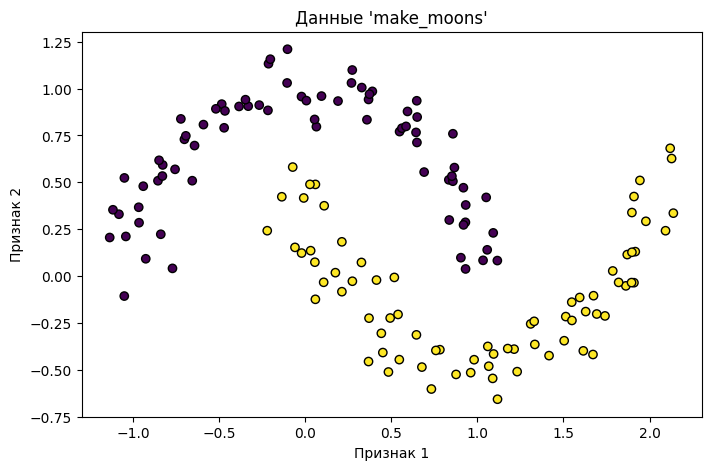

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Генерируем данные в форме двух лун
X_moons, y_moons = make_moons(n_samples=150, noise=0.1, random_state=42)

# Визуализируем исходные данные
plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', edgecolors='k')
plt.title("Данные 'make_moons'")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()

### **Шаг 2: Обучение моделей с разными ядрами**

Мы обучим два классификатора:
1.  `linear`: чтобы увидеть ограничения линейного подхода.
2.  `rbf`: чтобы увидеть мощь нелинейного разделения.

In [ ]:
from sklearn import svm

# Обучаем линейный SVM
clf_linear = svm.SVC(kernel='linear', C=1.0)
clf_linear.fit(X_moons, y_moons)

# Обучаем SVM с RBF ядром
# gamma - важный параметр для RBF, определяющий 'радиус влияния' одной точки
clf_rbf = svm.SVC(kernel='rbf', C=1.0, gamma=1.0)
clf_rbf.fit(X_moons, y_moons)

print("Обе модели успешно обучены.")

Обе модели успешно обучены.


### **Шаг 3: Визуализация границ решений**

Создадим функцию для отрисовки границ, чтобы наглядно сравнить работу двух ядер.

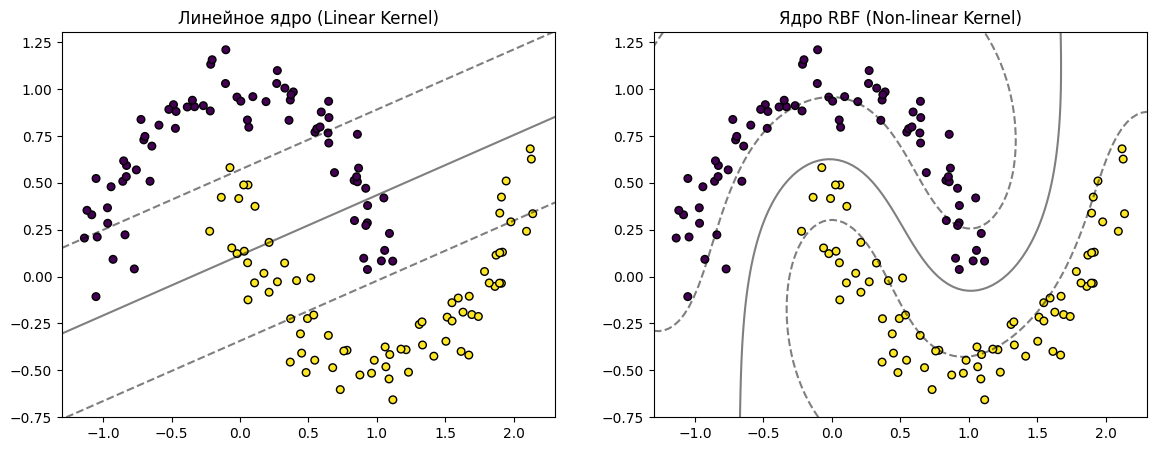

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_svc_decision_boundary(model, X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis', edgecolors='k')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # Отрисовка границы и зазоров
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    plt.title(title)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_svc_decision_boundary(clf_linear, X_moons, y_moons, "Линейное ядро (Linear Kernel)")

plt.subplot(1, 2, 2)
plot_svc_decision_boundary(clf_rbf, X_moons, y_moons, "Ядро RBF (Non-linear Kernel)")

plt.show()

### **Итоги и выводы по Заданию 2**

1.  **Линейное ядро** не смогло адекватно разделить данные `make_moons`, так как оно может строить только прямые линии. Часть данных неизбежно оказывается не на своей стороне.
2.  **Ядро RBF** успешно справилось с задачей, создав гибкую криволинейную границу, которая точно повторяет форму «лун».
3.  **Вывод**: Для сложных, нелинейных зависимостей RBF-ядро является мощным инструментом, позволяющим SVM находить сложные закономерности в данных без необходимости вручную создавать новые признаки.

### **Задание 3: Подбор параметров C и gamma с помощью GridSearchCV**

Эффективность SVM сильно зависит от правильного выбора гиперпараметров. Для RBF-ядра основными являются:
1.  **C**: Штраф за ошибки. Большое значение заставляет модель классифицировать все точки правильно, что может привести к переобучению. Маленькое — делает границу более гладкой.
2.  **gamma**: Определяет область влияния отдельной точки. Большое значение делает границу очень сложной и 'подстроенной' под конкретные точки. Маленькое — делает границу более широкой и плавной.

**Цели задания:**
1.  **Поиск по сетке**: Использовать `GridSearchCV` для автоматического перебора комбинаций параметров.
2.  **Анализ результатов**: Найти лучшую комбинацию признаков для данных `make_moons`.
3.  **Визуализация**: Сравнить, как меняются границы решений при разных значениях параметров.

### **Шаг 1: Настройка GridSearchCV**

Мы определим сетку параметров (диапазон значений C и gamma) и запустим процесс поиска. Библиотека `sklearn` сама разделит данные на обучающие и проверочные (cross-validation), чтобы найти наиболее стабильную модель.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Определяем сетку параметров для поиска
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 1, 5, 10],
    'kernel': ['rbf']
}

# Создаем объект GridSearchCV
grid = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=1, cv=5)

# Запускаем поиск
grid.fit(X_moons, y_moons)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший результат точности: {grid.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучшие параметры: {'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}
Лучший результат точности: 1.0000


### **Шаг 2: Визуализация влияния C и gamma**

Чтобы понять, как эти параметры меняют логику модели, построим графики для четырех разных комбинаций.

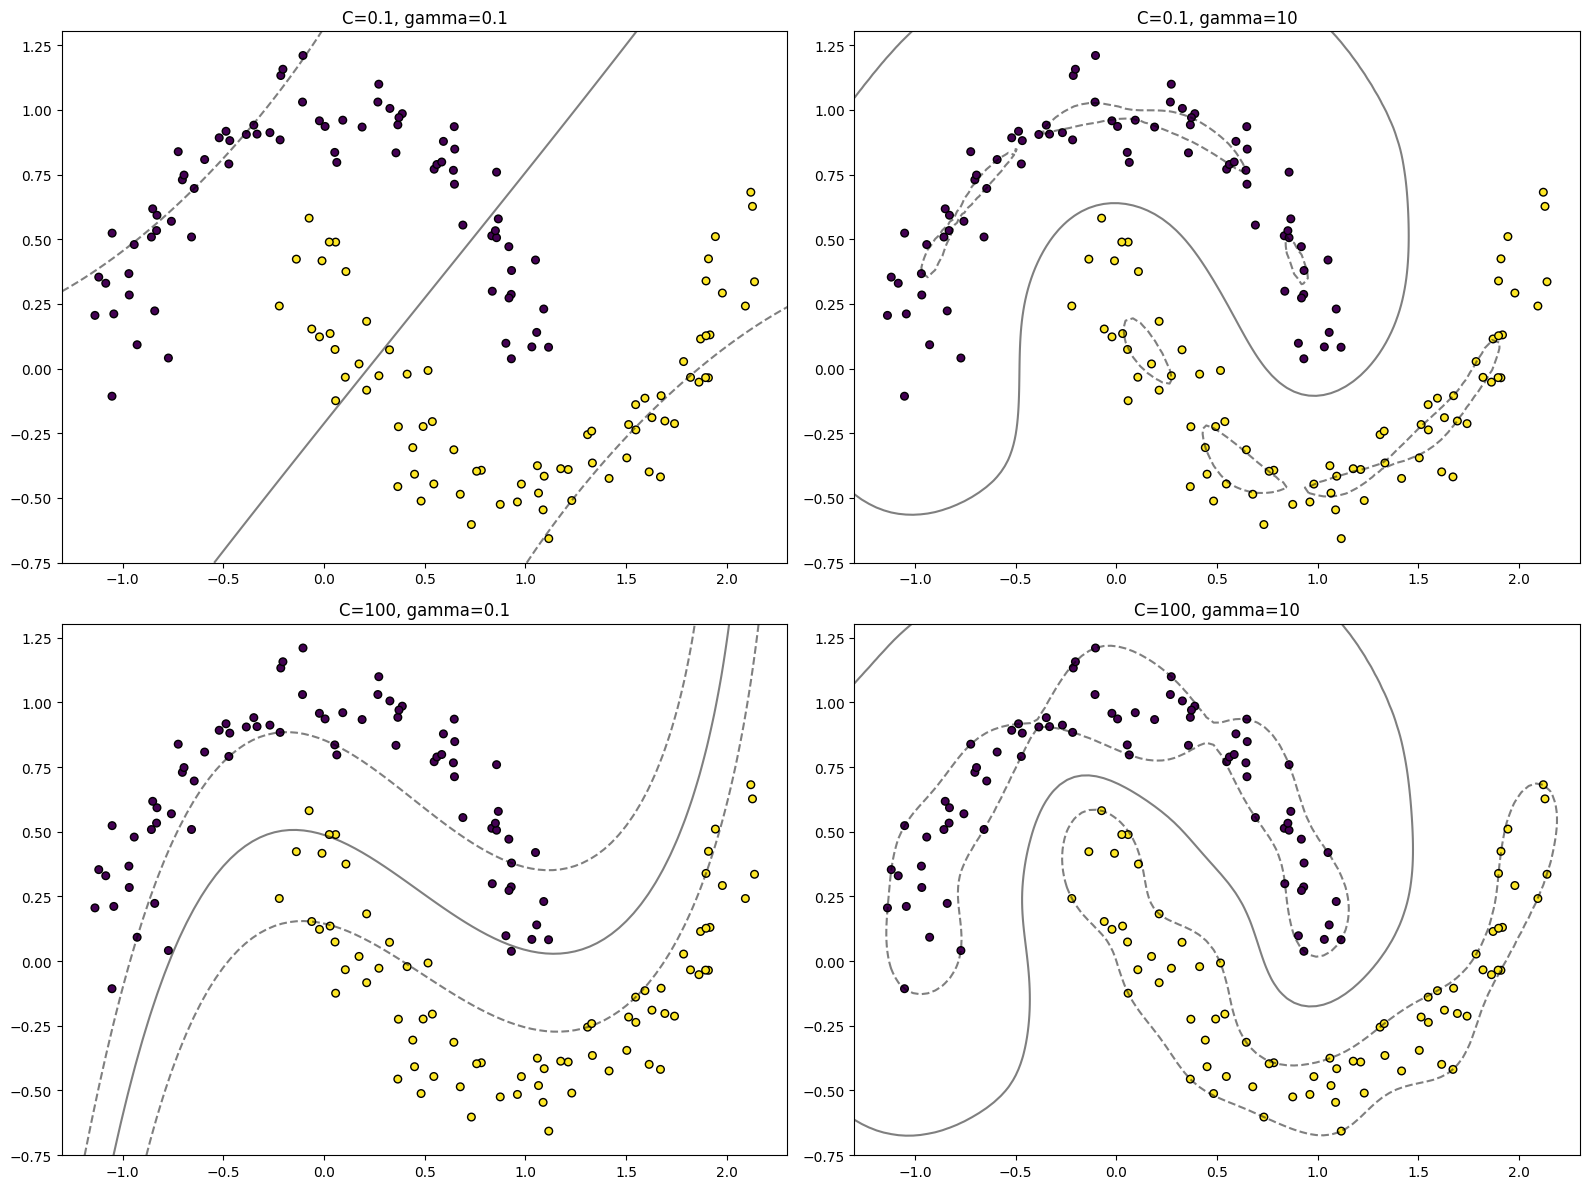

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Список комбинаций (C, gamma)
params = [(0.1, 0.1), (0.1, 10), (100, 0.1), (100, 10)]

plt.figure(figsize=(16, 12))

for i, (C_val, gamma_val) in enumerate(params):
    plt.subplot(2, 2, i+1)
    model = svm.SVC(kernel='rbf', C=C_val, gamma=gamma_val)
    model.fit(X_moons, y_moons)

    # Используем функцию из предыдущего задания (она должна быть определена в памяти)
    plot_svc_decision_boundary(model, X_moons, y_moons, f"C={C_val}, gamma={gamma_val}")

plt.tight_layout()
plt.show()

### **Итоги и выводы по Заданию 3**

1.  **Влияние Gamma**: При низком `gamma` (0.1) граница очень простая и сглаженная. При высоком `gamma` (10) модель начинает 'обволакивать' каждую точку, что может привести к потере обобщающей способности.
2.  **Влияние C**: Высокое `C` делает зазор более жестким, стремясь минимизировать любые ошибки на тренировочном наборе.
3.  **GridSearchCV** — это стандартный инструмент в машинном обучении, который позволяет не гадать с параметрами, а находить их математически обоснованно на основе кросс-валидации.

### **Задание 4: SVM vs Логистическая регрессия**

И SVM, и логистическая регрессия являются мощными алгоритмами классификации. Однако они работают по-разному: логистическая регрессия минимизирует логарифмические потери (Log Loss), а SVM максимизирует зазор (Margin).

**Цели задания:**
1.  **Сравнение**: Обучить обе модели на одном наборе данных.
2.  **Оценка**: Сравнить точность (accuracy) и визуализировать границы решений.
3.  **Вывод**: Понять, в каких случаях один алгоритм предпочтительнее другого.

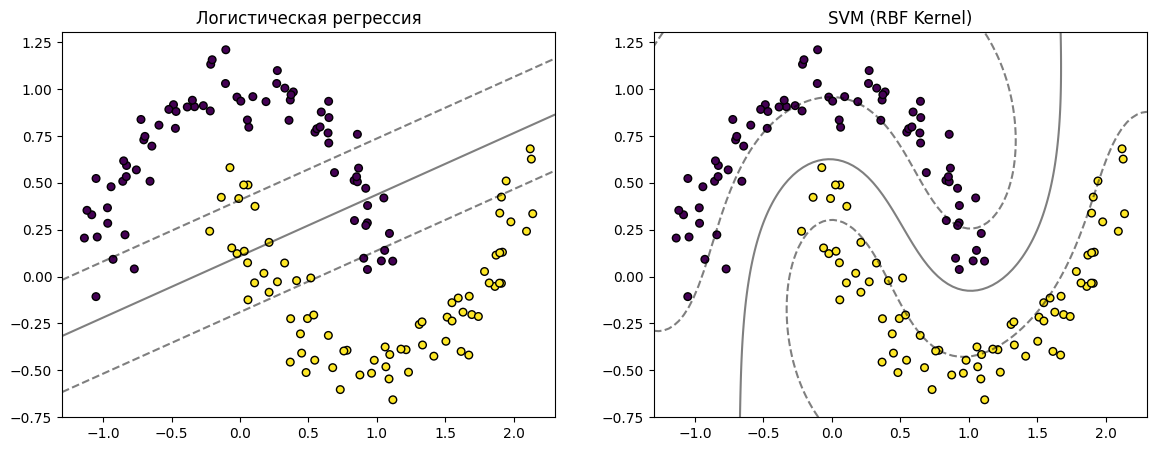

Accuracy LogReg: 0.85
Accuracy SVM: 1.00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Используем данные 'moons' из предыдущего задания
# Логистическая регрессия
log_reg = LogisticRegression()
log_reg.fit(X_moons, y_moons)

# SVM с RBF ядром
svm_model = svm.SVC(kernel='rbf', C=1.0, gamma=1.0)
svm_model.fit(X_moons, y_moons)

# Визуализация
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_svc_decision_boundary(log_reg, X_moons, y_moons, "Логистическая регрессия")

plt.subplot(1, 2, 2)
plot_svc_decision_boundary(svm_model, X_moons, y_moons, "SVM (RBF Kernel)")

plt.show()

print(f"Accuracy LogReg: {accuracy_score(y_moons, log_reg.predict(X_moons)):.2f}")
print(f"Accuracy SVM: {accuracy_score(y_moons, svm_model.predict(X_moons)):.2f}")

### **Задание 5: One-Class SVM для детекции аномалий**

One-Class SVM используется, когда у нас есть данные только одного класса («нормальные» данные), и нам нужно определить, является ли новый объект аномалией (выбросом).

**Цели задания:**
1.  **Генерация**: Создать нормальное распределение точек и добавить несколько случайных выбросов.
2.  **Обучение**: Использовать `svm.OneClassSVM` для поиска границ нормальности.
3.  **Визуализация**: Выделить найденные аномалии на графике.

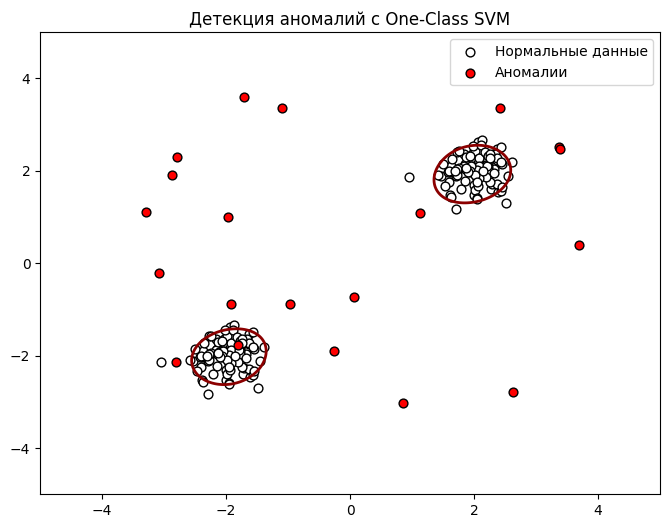

In [ ]:
# Генерация нормальных данных
X_train = 0.3 * np.random.randn(100, 2)
X_train = np.r_[X_train + 2, X_train - 2]

# Генерация аномалий (выбросов)
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

# Обучение модели
ocsvm = svm.OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
ocsvm.fit(X_train)

# Предсказание (1 - норма, -1 - аномалия)
y_pred_train = ocsvm.predict(X_train)
y_pred_outliers = ocsvm.predict(X_outliers)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c='white', s=40, edgecolors='k', label='Нормальные данные')
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', s=40, edgecolors='k', label='Аномалии')

# Отрисовка границы
xx, yy = np.meshgrid(np.linspace(-5, 5, 500), np.linspace(-5, 5, 500))
Z = ocsvm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')

plt.title("Детекция аномалий с One-Class SVM")
plt.legend()
plt.show()

# Список практических задач:

1.  Линейный SVM.  На линейно разделимых данных обучить SVM с линейным ядром. Визуализировать разделяющую полосу и опорные векторы.
2.  Ядро RBF.  На данных "луна" (make_moons) обучить SVM с RBF-ядром. Сравнить с линейным ядром и визуализировать границы решений.
3.  Подбор параметров C и gamma.  Использовать GridSearchCV для поиска оптимальных гиперпараметров. Визуализировать границы решений для разных комбинаций.
4.  SVM vs Логистическая регрессия.  На одном датасете сравнить качество SVM и логистической регрессии. Определить, когда SVM выигрывает.
5.  One-Class SVM для детекции аномалий.  Обучить One-Class SVM на "нормальных" данных и найти выбросы.


### **Задание 1: Линейный SVM на линейно разделимых данных**

В этом задании мы с вами погрузимся в мир машин поддержки векторов (SVM) с линейным ядром. Ваша задача — понять, как SVM находит оптимальную разделяющую гиперплоскость между классами и как определяются **опорные векторы**, которые играют ключевую роль в этом процессе.

**Цели задания:**
1.  **Генерация данных**: Создать набор данных, который можно линейно разделить.
2.  **Обучение SVM**: Обучить модель SVM с линейным ядром на этих данных.
3.  **Визуализация**: Построить график, показывающий:
    *   Точки данных, окрашенные по классам.
    *   Оптимальную разделяющую гиперплоскость (линию).
    *   Полосу максимального зазора (маржи).
    *   Опорные векторы, выделенные особым образом.

Это задание поможет вам заложить прочный фундамент для понимания более сложных ядер SVM и их применения.

### **Шаг 1: Импорт необходимых библиотек**

Прежде чем начать, нам нужно импортировать все библиотеки, которые мы будем использовать. Это стандартная практика в Python для организации кода и обеспечения доступности всех необходимых функций.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

print("Все необходимые библиотеки импортированы.")

Все необходимые библиотеки импортированы.


### **Шаг 2: Генерация линейно разделимых данных**

Для нашего первого задания нам нужен простой набор данных, который можно четко разделить прямой линией. Для этого мы будем использовать функцию `make_blobs` из библиотеки `sklearn.datasets`. Она позволяет генерировать группы (кластеры) точек с заданным количеством центров и стандартным отклонением, что идеально подходит для создания линейно разделимых классов.

Мы создадим два кластера точек, расположенных таким образом, чтобы между ними можно было провести прямую линию, разделяющую их.

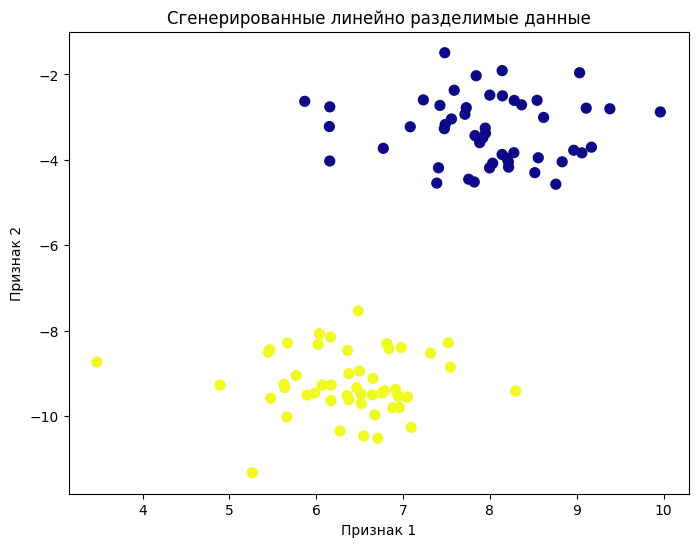

Линейно разделимые данные успешно сгенерированы и визуализированы.


In [ ]:
# Генерируем 100 точек данных, разделенных на 2 кластера
# 'centers' определяет координаты центров кластеров
# 'cluster_std' определяет стандартное отклонение точек внутри кластеров (насколько они разбросаны)
# 'random_state' обеспечивает воспроизводимость результатов
X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=0.8)

# Визуализируем сгенерированные данные, чтобы убедиться, что они линейно разделимы
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='plasma')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Сгенерированные линейно разделимые данные')
plt.show()

print("Линейно разделимые данные успешно сгенерированы и визуализированы.")

### **Шаг 3: Обучение модели SVM с линейным ядром**

Теперь, когда у нас есть данные, мы можем обучить модель SVM. Для линейного SVM мы используем класс `svm.SVC` (Support Vector Classifier) с параметром `kernel='linear'`.

*   **`C` (Regularization parameter)**: Это параметр регуляризации. Он контролирует компромисс между достижением большого зазора (маржи) и правильной классификацией обучающих точек. Маленькое значение `C` создает большую маржу, но может привести к большему количеству ошибок классификации. Большое `C` стремится к правильной классификации всех обучающих точек, но может уменьшить маржу и привести к переобучению.

После создания объекта классификатора мы вызываем метод `fit()` для обучения модели на наших данных `X` и их метках `y`.

In [ ]:
# Создаем экземпляр SVM-классификатора с линейным ядром
# C=1000 - большое значение, чтобы модель стремилась к жесткому разделению (hard-margin SVM),
# поскольку данные линейно разделимы и шум минимален.
clf = svm.SVC(kernel='linear', C=1000)

# Обучаем модель на наших данных
clf.fit(X, y)

print("Модель SVM с линейным ядром успешно обучена.")
print(f"Количество опорных векторов: {len(clf.support_vectors_)}")

Модель SVM с линейным ядром успешно обучена.
Количество опорных векторов: 2


### **Шаг 4: Визуализация разделяющей полосы и опорных векторов**

Это самый наглядный шаг, который поможет вам понять, как работает линейный SVM. Мы визуализируем:

*   **Точки данных**: Цветом будут обозначены классы.
*   **Разделяющую гиперплоскость (линию решений)**: Это граница, которая максимально разделяет классы.
*   **Маржу (зазор)**: Две параллельные линии, расположенные по обе стороны от гиперплоскости решений. Расстояние между этими линиями SVM старается максимизировать.
*   **Опорные векторы**: Это те точки данных, которые лежат *точно на границах маржи*. Они критически важны для определения разделяющей гиперплоскости и маржи. Если удалить любые другие точки, кроме опорных векторов, гиперплоскость и маржа не изменятся. Если же удалить опорный вектор, то изменится.

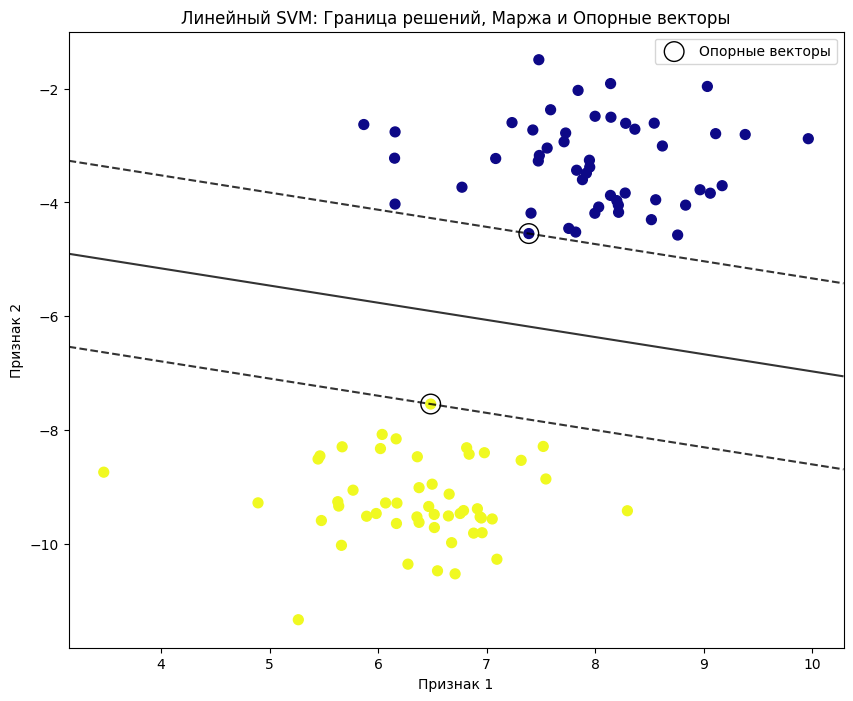

Визуализация SVM: граница решений, маржа и опорные векторы отображены.


In [ ]:
plt.figure(figsize=(10, 8))

# 1. Отображаем точки данных
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='plasma')

# 2. Отображаем опорные векторы
# support_vectors_ атрибут хранит координаты опорных векторов
plt.scatter(clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='k', label='Опорные векторы')

# 3. Строим разделяющую гиперплоскость и маржи
# Для 2D данных гиперплоскость - это линия вида w0*x + w1*y + b = 0
# Коэффициенты w (clf.coef_[0]) и смещение b (clf.intercept_[0]) позволяют нам построить эту линию.

ax = plt.gca() # Получаем текущие оси для дальнейших манипуляций
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Создаем сетку точек для оценки решений
x = np.linspace(xlim[0], xlim[1], 30)
y = np.linspace(ylim[0], ylim[1], 30)
Y, X = np.meshgrid(y, x)
xy = np.vstack([X.ravel(), Y.ravel()]).T

# Вычисляем функцию решения для каждой точки сетки
# clf.decision_function(xy) возвращает "расстояние" каждой точки до гиперплоскости
P = clf.decision_function(xy).reshape(X.shape)

# Рисуем разделяющую гиперплоскость (P=0) и маржи (P=-1 и P=1)
ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.8, linestyles=['--', '-', '--'])

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Линейный SVM: Граница решений, Маржа и Опорные векторы')
plt.legend()
plt.show()

print("Визуализация SVM: граница решений, маржа и опорные векторы отображены.")

### **Итоги и выводы по Заданию 1**

Поздравляю! Вы успешно выполнили первое задание:

1.  **Сгенерировали** линейно разделимые данные.
2.  **Обучили** модель SVM с линейным ядром.
3.  **Визуализировали** ключевые элементы: точки данных, разделяющую гиперплоскость, маржу и опорные векторы.

**Ключевые понятия, которые вы должны были освоить:**

*   **Линейно разделимые данные**: Наборы данных, которые можно разделить прямой линией (или гиперплоскостью в многомерном пространстве).
*   **Линейный SVM**: Модель, которая находит оптимальную разделяющую гиперплоскость, максимизирующую зазор (маржу) между классами.
*   **Опорные векторы**: Точки данных, наиболее близкие к разделяющей гиперплоскости. Именно они определяют положение гиперплоскости и размер маржи. Удаление других точек не повлияет на модель, но удаление опорных векторов изменит её.
*   **Маржа (зазор)**: Область вокруг разделяющей гиперплоскости, свободная от точек данных. SVM стремится сделать эту маржу максимально широкой.

Это понимание является фундаментом для перехода к более сложным задачам, где данные не всегда линейно разделимы, и где на помощь приходят **ядерные функции (Kernel Trick)**, которые мы рассмотрим в следующем задании. Теперь вы готовы самостоятельно изучать и выполнять следующие задачи из списка!